# DNA viral diversity and community composition

In [ ]:
## "Alpha diversity across infaunal treatments; PCoA and PERMANOVA"

PROJ <- "./" #
if (!dir.exists(PROJ)) PROJ <- "."
PROJ <- normalizePath(PROJ, mustWork = TRUE)

knitr::opts_knit$set(root.dir = PROJ)   # applies when knitting
setwd(PROJ)                             # applies when running chunks interactively

dir.create(file.path(PROJ, "outputs", "figures"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(PROJ, "outputs", "tables"),  recursive = TRUE, showWarnings = FALSE)

knitr::opts_chunk$set(echo = TRUE, message = FALSE, warning = FALSE,
                      fig.path = "outputs/figures/", dpi = 300)

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 119 taxa and 26 samples ]
sample_data() Sample Data:       [ 26 samples by 2 sample variables ]
tax_table()   Taxonomy Table:    [ 119 taxa by 6 taxonomic ranks ]

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have alrea

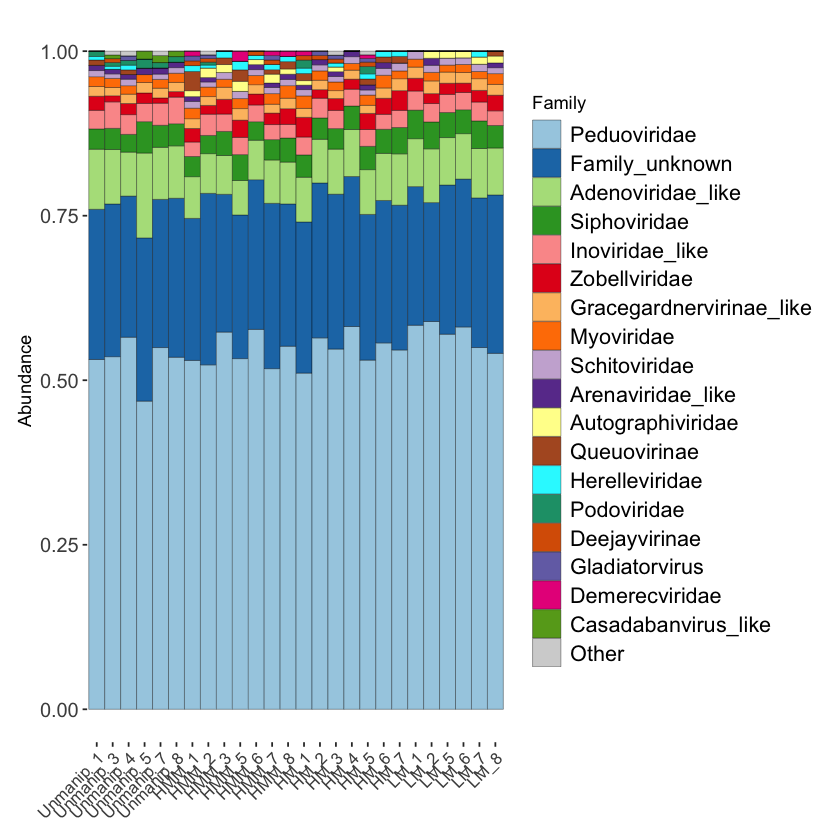

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have alrea

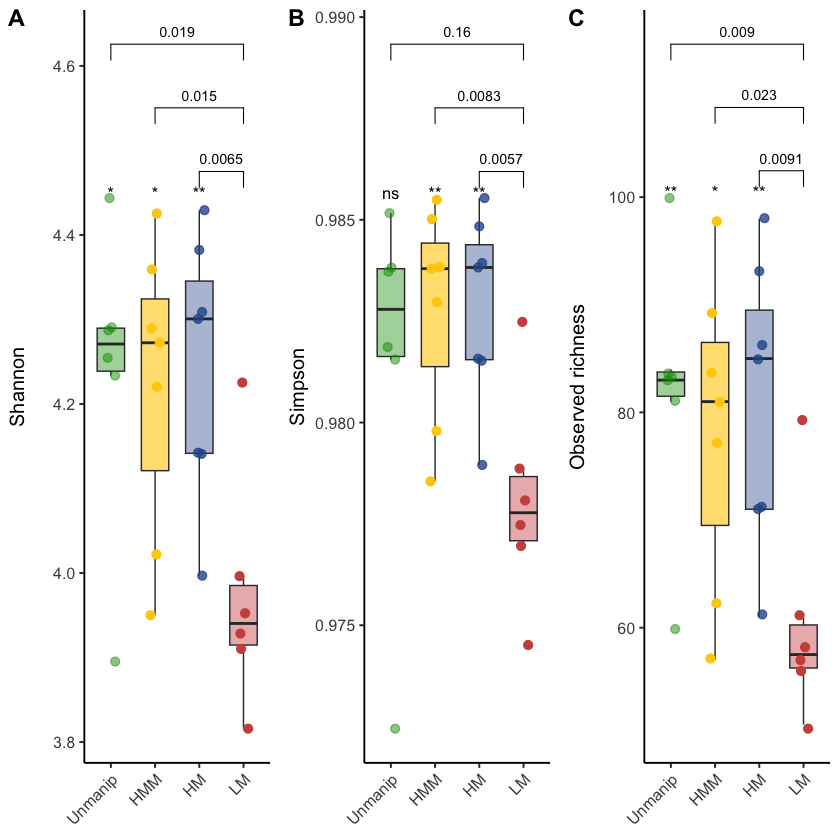

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Condition,3,0.1543123,0.3672313,4.255945,6e-04
Residual,22,0.2658924,0.6327687,NA,NA
Total,25,0.4202047,1.0000000,NA,NA


R version 4.1.1 (2021-08-10)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS 26.4.1

Matrix products: default
BLAS/LAPACK: /Users/au657143/mambaforge/envs/maaslin/lib/libopenblasp-r0.3.23.dylib

locale:
[1] en_AU/en_AU/en_AU/C/en_AU/en_AU

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] microViz_0.12.1 dplyr_1.1.4     ggpubr_0.6.0    ggplot2_3.5.2  
[5] vegan_2.6-4     lattice_0.21-8  permute_0.9-7   phyloseq_1.38.0

loaded via a namespace (and not attached):
 [1] nlme_3.1-162           bitops_1.0-9           RColorBrewer_1.1-3    
 [4] GenomeInfoDb_1.30.1    repr_1.1.6             tools_4.1.1           
 [7] backports_1.4.1        R6_2.6.1               BiocGenerics_0.40.0   
[10] mgcv_1.9-0             colorspace_2.1-0       rhdf5filters_1.6.0    
[13] ade4_1.7-22            withr_3.0.2            tidyselect_1.2.1      
[16] compiler_4.1.1         microbiome_1.16.0      textshaping_0.3.7

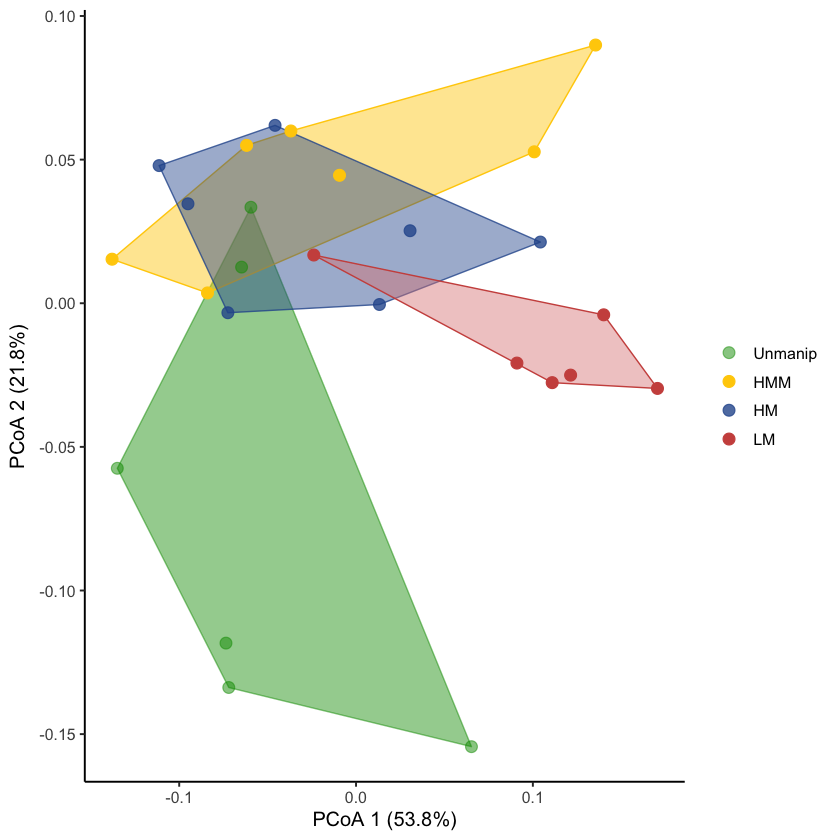

In [6]:
# R libraries

library(phyloseq)   # object model, ordination, richness
library(vegan)      # vegdist, adonis2
library(ggplot2)    # all plotting
library(ggpubr)     # significance brackets, panel assembly
library(dplyr)
library(microViz)

## Figure style

LEVELS <- c("Unmanip", "HMM", "HM", "LM")

COL_POINT <- c(Unmanip = "#00970080",   # points, dots
               HMM  = "#ffce04ff",
               HM   = "#2a579bcb",
               LM   = "#cd534cff")

COL_FILL  <- c(Unmanip = "#00970066",   # box fills, ordination hulls
               HMM  = "#ffcc0099",
               HM   = "#2a579b66",
               LM   = "#de87879a")

OUTLINE <- "grey20"

save_fig <- function(plot, name, width, height) {
  ggsave(file.path("outputs", "figures", paste0(name, ".pdf")),
         plot, width = width, height = height)
  if (requireNamespace("svglite", quietly = TRUE))
    ggsave(file.path("outputs", "figures", paste0(name, ".svg")),
           plot, width = width, height = height)
  invisible(plot)
}

## Build the phyloseq object

otus <- read.table("data/DNA_virus_119Genomes.txt", header = TRUE, sep = "\t")
rownames(otus) <- otus$Genomes
otu_mat <- as.matrix(otus[, -1])            # all columns except the genome ID

tax <- read.table("data/Taxonomy_119Genomes.txt", header = TRUE, sep = "\t")
rownames(tax) <- tax$ASVs
tax_mat <- as.matrix(tax[, 2:7])            # six taxonomic ranks

sampledata <- read.table("data/env_samples.txt", header = TRUE, sep = "\t")
rownames(sampledata) <- sampledata$Samples

# 1. Set Condition as an ordered factor
sampledata$Condition <- factor(sampledata$Condition, levels = LEVELS)

# 2. Re-order sampledata rows explicitly by Condition
sampledata <- sampledata[order(sampledata$Condition), ]

# 3. Re-align otu_mat columns to match the newly ordered sampledata rows
otu_mat <- otu_mat[, rownames(sampledata)]

# 4. Build phyloseq object
physeq <- phyloseq(otu_table(otu_mat, taxa_are_rows = TRUE),
                   tax_table(tax_mat),
                   sample_data(sampledata))

# 5. Drop genomes absent from every sample
virus.prune <- prune_taxa(taxa_sums(physeq) > 0, physeq)

# 6. Apply microViz ps_mutate and ps_arrange to ensure internal slots stay ordered
virus.prune <- virus.prune %>%
  ps_mutate(Condition = factor(Condition, levels = LEVELS)) %>%
  ps_arrange(Condition)

virus.prune


#### Distribution and abundance of DNA viral community ####
## DNA virus abundance - Barplot

plot.dna.virus <- physeq %>%  tax_fix() %>% 
  comp_barplot("Family", n_taxa = 18, sample_order = "asis",
    bar_outline_colour = "black",                
  )  %>%
  patchwork::wrap_plots(nrow = 1, guides = "collect") & 

theme(axis.text.x = element_text(angle = 45, hjust = 1), axis.ticks.x = element_line())  &  #coord_flip() &
  theme(
    axis.text.y = element_text(size = 12),
    axis.text.x = element_text(size = 10),
    legend.text = element_text(size = 13),
    legend.position = "right" 
  )

plot.dna.virus 


#### Alpha diversity ####

#> **Statistical test: he code below uses `t.test`


TEST <- "t.test"          
div_data <- function(measure) {
  d <- plot_richness(virus.prune, measures = measure)$data
  d$Condition <- factor(d$Condition, levels = LEVELS)
  d
}

comparisons <- list(c("LM", "HM"), c("LM", "HMM"), c("LM", "Unmanip"))

div_panel <- function(measure, ylab) {
  ggplot(div_data(measure), aes(Condition, value)) +
    geom_boxplot(aes(fill = Condition), colour = OUTLINE,
                 linewidth = 0.4, outlier.shape = NA, width = 0.62) +
    geom_point(aes(colour = Condition), size = 2.2,
               position = position_jitter(width = 0.12, seed = 1)) +
    scale_fill_manual(values = COL_FILL,  drop = FALSE) +
    scale_colour_manual(values = COL_POINT, drop = FALSE) +
    stat_compare_means(comparisons = comparisons, method = TEST, size = 3) +
    stat_compare_means(aes(label = after_stat(p.signif)),
                       method = TEST, ref.group = "LM", size = 3.5) +
    labs(x = NULL, y = ylab) +
    theme_classic(base_size = 12) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "none")
}

p_shannon <- div_panel("Shannon",  "Shannon")
p_simpson <- div_panel("Simpson",  "Simpson")
p_obs     <- div_panel("Observed", "Observed richness")


#Pairwise comparisons are made against LM only — the low-meiofauna end of the gradient — rather
#than all pairs, because that is the contrast the design was built to test.

fig_1c <- ggarrange(p_shannon, p_simpson, p_obs,
                    labels = c("A", "B", "C"),
                    ncol = 3, nrow = 1, align = "v")

save_fig(fig_1c, "Fig_1C_DNA_viral_diversity", width = 10, height = 4)
fig_1c


# Export the underlying values for Supplementary Table 2:

bind_rows(
  transform(div_data("Shannon"),  index = "Shannon"),
  transform(div_data("Simpson"),  index = "Simpson"),
  transform(div_data("Observed"), index = "Observed")
) %>%
  select(Sample = samples, Condition, index, value) %>%
  write.csv("outputs/tables/01_alpha_diversity.csv", row.names = FALSE)


## Community composition
### Relative abundance

#Converted to percentages per sample. Bray–Curtis is insensitive to this rescaling, but it makes
#the table directly comparable with the family-level figures.

phy.norm  <- transform_sample_counts(virus.prune, function(x) x / sum(x) * 100)
otu_reads <- otu_table(t(phy.norm), taxa_are_rows = FALSE)   # samples in rows

### PCoA

#PCoA (metric multidimensional scaling) places samples in a low-dimensional space that preserves
#their pairwise dissimilarities. Unlike PCA it accepts any dissimilarity index.

#Axis labels report the proportion of variation each axis represents.'''


bray_dist <- vegan::vegdist(otu_reads, method = "bray")
ord       <- ordinate(phy.norm, "PCoA", distance = bray_dist)

pct <- round(100 * ord$values$Relative_eig[1:2], 1)

ord_df <- plot_ordination(phy.norm, ord, color = "Condition", justDF = TRUE)
ord_df$Condition <- factor(ord_df$Condition, levels = LEVELS)

hulls <- ord_df %>%
  group_by(Condition) %>%
  slice(chull(Axis.1, Axis.2)) %>%
  ungroup()

fig_1e <- ggplot(ord_df, aes(Axis.1, Axis.2)) +
  geom_polygon(data = hulls, aes(fill = Condition, colour = Condition),
               alpha = 0.45, linewidth = 0.4, show.legend = FALSE) +
  geom_point(aes(colour = Condition), size = 3) +
  scale_fill_manual(values = COL_FILL,  drop = FALSE) +
  scale_colour_manual(values = COL_POINT, drop = FALSE) +
  labs(x = paste0("PCoA 1 (", pct[1], "%)"),
       y = paste0("PCoA 2 (", pct[2], "%)"),
       colour = NULL) +
  theme_classic(base_size = 12) +
  theme(legend.position = "right")

save_fig(fig_1e, "Fig_1E_DNA_viral_PCoA", width = 5.5, height = 4.5)
fig_1e


### PERMANOVA

#Tests whether treatment explains the dissimilarity structure. The distance matrix and the
#metadata are aligned explicitly by sample name — `adonis2()` matches rows positionally.

meta <- as(sample_data(phy.norm), "data.frame")[attr(bray_dist, "Labels"), , drop = FALSE]
stopifnot(identical(rownames(meta), attr(bray_dist, "Labels")))

set.seed(1)
pm <- adonis2(bray_dist ~ Condition, data = meta, permutations = 9999)
pm

write.csv(as.data.frame(pm), "outputs/tables/01_permanova_condition.csv")


#The R² is the proportion of variation in viral community composition attributable to the
#infaunal treatments, and is the value quoted in the Results.

sessionInfo()
